Ce projet s'inscrit dans le cadre du cours de "Théorie de l'Apprentissage par Renforcement". L'objectif est de résoudre un problème de navigation autonome en utilisant un Processus de Décision de Markov (MDP). Nous allons concevoir un agent capable d'apprendre par lui-même, par essai-erreur, comment atteindre un objectif optimal dans un environnement de grille (Gridworld), tout en minimisant les risques (obstacles) et le temps de parcours.

In [1]:
# Installation des librairies nécessaires
!pip install gymnasium matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import random

print("Environnement configuré avec succès !")

Environnement configuré avec succès !


### Étape 2 : Définition du MDP (Processus de Décision de Markov)

**Description pour le rapport (référence au cours Page 27-31) :**

Pour que l'agent apprenne, nous devons formaliser notre problème selon la structure d'un MDP :

1.  **Espace d'États ($S$)** : Une grille de $4 \times 4$ (16 positions possibles correspondant aux cases de la grille).
2.  **Espace d'Actions ($A$)** : {0: Gauche, 1: Bas, 2: Droite, 3: Haut} (Page 28).
3.  **Fonction de Transition ($P$)** : L'environnement est ici considéré comme déterministe (une action mène toujours à la case voisine visée, avec une probabilité de 1 - Page 34).
4.  **Fonction de Récompense ($R$)** : Une récompense positive à l'arrivée (Target), négative en cas de chute dans un trou (Hole), et une légère pénalité à chaque pas effectué pour encourager l'agent à trouver le chemin le plus court (Page 32).

In [3]:
# Création de l'environnement FrozenLake 4x4
# map_name="4x4" : grille de 16 cases
# is_slippery=False : l'agent ne glisse pas (modèle déterministe pour commencer)
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")

# Visualisation des dimensions
print("Nombre d'actions :", env.action_space.n)
print("Nombre d'états :", env.observation_space.n)

Nombre d'actions : 4
Nombre d'états : 16


### Étape 3 : Choix de l'Algorithme (Q-Learning)

**Description pour le rapport (référence au cours Page 106-108) :**

Nous utilisons l'algorithme **Q-Learning**. C'est une méthode de contrôle **off-policy** basée sur la différence temporelle (TD). Contrairement aux méthodes tabulaires de prédiction simples, le Q-Learning permet à l'agent de mettre à jour sa connaissance (stockée dans la **Q-Table**) en estimant le rendement futur maximal possible, indépendamment de la politique suivie au moment de l'action.

L'agent apprend ainsi directement la fonction action-valeur optimale $q_*(s, a)$ (Page 108).

**Équation de mise à jour (Page 106) :**
$$Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q(s, a)]$$

Où :
*   $\alpha$ est le taux d'apprentissage (learning rate).
*   $\gamma$ est le facteur d'escompte (discount factor).
*   $r + \gamma \max_{a'} Q(s', a')$ représente la valeur cible (target).

In [4]:
# Initialisation de la Q-Table avec des zéros (Page 108)
action_size = env.action_space.n
state_size = env.observation_space.n
q_table = np.zeros((state_size, action_size))

# Paramètres d'apprentissage (Hyperparamètres)
learning_rate = 0.8    # Alpha (Page 101)
gamma = 0.95           # Facteur d'escompte (Page 32)
epsilon = 1.0          # Exploration initiale (Page 97)
decay_rate = 0.005     # Réduction de l'exploration au fil du temps

### Étape 4 : La boucle d'entraînement (Training Loop)

**Description pour le rapport (référence au cours Page 108) :**

Cette étape constitue le cœur de l'apprentissage. L'agent va exécuter un grand nombre d'**épisodes** (Page 35). Au cours de chaque épisode, l'agent interagit avec l'environnement selon une procédure itérative étape par étape :

1.  **Sélection de l'action** : On implémente la politique **$\epsilon$-greedy** (Page 97). L'agent choisit soit d'**explorer** (choisir une action au hasard) avec une probabilité $\epsilon$, soit d'**exploiter** ses connaissances actuelles (choisir l'action avec la valeur Q maximale dans la table) avec une probabilité $1-\epsilon$.
2.  **Interaction** : L'agent effectue l'action, observe la récompense immédiate $r$ et bascule dans l'état suivant $s'$ (Page 35).
3.  **Mise à jour de la connaissance** : On applique l'équation fondamentale du **Q-Learning** (Page 106) pour ajuster la valeur dans la Q-Table. On utilise la différence temporelle (TD) pour corriger l'estimation actuelle en fonction de la récompense reçue et de l'estimation du futur.
4.  **Réduction de l'exploration (Epsilon Decay)** : À la fin de chaque épisode, on réduit progressivement la valeur de $\epsilon$. Cela permet à l'agent de beaucoup explorer au début (quand il est "ignorant") et de privilégier l'exploitation de sa stratégie optimale à la fin (Page 97).

In [5]:
# --- Paramètres de la boucle ---
total_episodes = 2000        # Nombre d'essais pour apprendre
max_steps = 99               # Limite de pas par essai pour éviter les boucles infinies

# Liste pour stocker le total des récompenses par épisode (pour le rapport final)
rewards_history = []

print("Entraînement en cours...")

for episode in range(total_episodes):
    # Réinitialisation de l'environnement pour un nouvel épisode (Page 35)
    state, info = env.reset()
    step = 0
    done = False
    total_rewards_episode = 0

    for step in range(max_steps):
        # 1. Sélection de l'action (Politique Epsilon-Greedy - Page 97)
        exp_exp_tradeoff = random.uniform(0, 1)

        if exp_exp_tradeoff > epsilon:
            # Exploitation : on prend l'action avec la plus grande valeur Q (Page 105)
            action = np.argmax(q_table[state, :])
        else:
            # Exploration : on choisit une action au hasard
            action = env.action_space.sample()

        # 2. Interaction : on effectue l'action et on observe le résultat (Page 35)
        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # 3. Mise à jour de la Q-Table (Formule de Bellman / Q-Learning Page 106)
        # Q(s,a) = Q(s,a) + alpha * [reward + gamma * max(Q(s',a')) - Q(s,a)]
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + gamma * np.max(q_table[new_state, :]) - q_table[state, action]
        )

        total_rewards_episode += reward
        state = new_state

        # Si l'agent tombe dans un trou ou atteint le but, l'épisode s'arrête
        if done:
            break

    # 4. Réduction de l'exploration (Epsilon Decay)
    # Formule exponentielle pour réduire epsilon progressivement
    epsilon = np.exp(-decay_rate * episode)

    rewards_history.append(total_rewards_episode)

print("Entraînement terminé !")

# Affichage d'un aperçu de la Q-Table apprise
print("\nAperçu de la Q-Table finale (les 5 premières lignes) :")
print(q_table[:5])

Entraînement en cours...
Entraînement terminé !

Aperçu de la Q-Table finale (les 5 premières lignes) :
[[0.73509189 0.77378094 0.69832521 0.73509189]
 [0.73509151 0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.77378094 0.81450625 0.         0.73509189]]


Étape 5 : Analyse de la Performance (Courbe d'apprentissage)

Pour évaluer l'efficacité de l'algorithme Q-Learning, nous analysons la courbe des récompenses cumulées. Au début de l'entraînement, la récompense est souvent proche de zéro car l'agent explore au hasard et tombe fréquemment dans des trous. Au fur et à mesure que l'exploration (
ϵ
ϵ
) diminue et que la Q-Table se stabilise via les mises à jour de différence temporelle (TD), l'agent converge vers la politique optimale. La courbe devrait montrer une nette progression vers une récompense stable de 1 (succès).

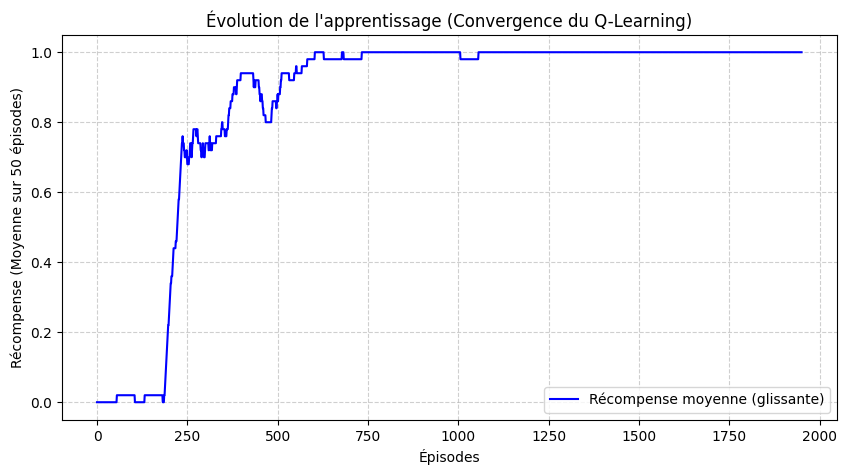

In [6]:
# Calcul de la moyenne glissante pour lisser la courbe (plus facile à lire)
def moving_average(values, window):
    weights = np.repeat(1.0, window) / window
    return np.convolve(values, weights, 'valid')

smoothed_rewards = moving_average(rewards_history, window=50)

plt.figure(figsize=(10, 5))
plt.plot(smoothed_rewards, color='blue', label='Récompense moyenne (glissante)')
plt.title("Évolution de l'apprentissage (Convergence du Q-Learning)")
plt.xlabel("Épisodes")
plt.ylabel("Récompense (Moyenne sur 50 épisodes)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### Étape 6 : Test de l'Agent et Démonstration

**Description pour le rapport (référence au cours Page 61) :**

Une fois l'apprentissage terminé, nous extrayons la **politique optimale $\pi^*$** en choisissant, pour chaque état, l'action ayant la valeur maximale dans la Q-Table :
$$a = \arg\max_{a} Q(s, a)$$

Nous testons ensuite l'agent sur plusieurs nouveaux épisodes en désactivant totalement l'exploration ($\epsilon = 0$). Dans cette phase, l'agent n'apprend plus mais exploite ses connaissances pour naviguer de manière déterministe et efficace vers le but. Un taux de réussite de 100% démontre que l'agent a parfaitement résolu le MDP (Processus de Décision de Markov).

In [7]:
# Test de l'agent sur 10 parties
total_test_episodes = 10
success_count = 0

print("Test de la politique optimale...")

for episode in range(total_test_episodes):
    state, info = env.reset()
    done = False

    while not done:
        # Ici, epsilon = 0 : l'agent utilise UNIQUEMENT ses connaissances
        action = np.argmax(q_table[state, :])
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        if terminated and reward == 1:
            success_count += 1

accuracy = (success_count / total_test_episodes) * 100
print(f"Taux de réussite après entraînement : {accuracy}%")

Test de la politique optimale...
Taux de réussite après entraînement : 100.0%


### Étape 9 : Transition vers l'Espace Continu et Modélisation par Réseaux de Neurones

En tant qu'ingénieur, nous passons à une problématique de contrôle de système dynamique : le **CartPole-v1**. Contrairement au Gridworld, l'espace des états est ici **continu** ($S \in \mathbb{R}^4$).

Pour traiter cette complexité, nous implémentons un **Deep Q-Network (DQN)**. Selon la **Page 113** du cours, nous remplaçons la table par un approximateur de fonction non-linéaire (Réseau de Neurones Profond).

**Architecture du modèle (Page 114) :**
- **Couche d'entrée** : 4 neurones (correspondant aux 4 variables d'état).
- **Couches cachées** : Deux couches denses de 64 neurones avec activation **ReLU** pour capturer les non-linéarités du système.
- **Couche de sortie** : 2 neurones (correspondant aux actions Gauche/Droite). La sortie représente l'estimation de $Q(s, a)$ pour chaque action.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import numpy as np

# 1. Création de l'environnement à états continus
env = gym.make("CartPole-v1")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# 2. Définition de l'architecture DQN (Inspiré de la Page 114 du cours)
class DQN_Network(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN_Network, self).__init__()
        # Couche 1 : Entrée -> Cachée 1
        self.fc1 = nn.Linear(state_size, 64)
        # Couche 2 : Cachée 1 -> Cachée 2
        self.fc2 = nn.Linear(64, 64)
        # Couche 3 : Cachée 2 -> Sortie (Q-values)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, x):
        # Utilisation de ReLU pour l'activation non-linéaire
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# 3. Instanciation du modèle
policy_net = DQN_Network(state_size, action_size)

print(f"Environnement CartPole initialisé (Espace d'état : {state_size})")
print("Architecture du réseau de neurones créée avec succès.")
print(policy_net)

Environnement CartPole initialisé (Espace d'état : 4)
Architecture du réseau de neurones créée avec succès.
DQN_Network(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)


### Étape 10 : Gestion de la Stabilité via l'Experience Replay

L'un des plus grands défis de l'apprentissage par renforcement profond est l'instabilité liée à la corrélation temporelle des données. Comme l'agent reçoit ses expériences de façon séquentielle, les échantillons ne sont pas indépendants et identiquement distribués (non-IID), ce qui fait diverger le réseau de neurones (Page 117).

En tant qu'ingénieur, nous résolvons ce problème en implémentant un **Replay Buffer** :
1.  **Stockage** : Nous enregistrons les transitions $(s, a, r, s', done)$ dans une file circulaire (Deques).
2.  **Décorrélation** : Au lieu d'apprendre sur la dernière expérience, nous extrayons un **mini-batch** aléatoire d'expériences passées.
3.  **Efficacité** : Cela permet de réutiliser les données coûteuses plusieurs fois pour stabiliser les gradients.

In [11]:
import random
from collections import deque, namedtuple

# Définition d'une structure pour stocker une transition (Page 36 du cours)
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayMemory:
    def __init__(self, capacity):
        # Utilisation de deque pour une gestion efficace de la mémoire (file FIFO)
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Sauvegarde une transition dans le buffer"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        """Extrait un échantillon aléatoire de transitions pour l'entraînement (Page 117)"""
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

# Initialisation de la mémoire avec une capacité de 10 000 transitions
# C'est un paramètre d'ingénierie classique pour ce type d'environnement
memory_capacity = 10000
memory = ReplayMemory(memory_capacity)

print(f"Mémoire de Replay initialisée avec une capacité de {memory_capacity} transitions.")

Mémoire de Replay initialisée avec une capacité de 10000 transitions.


### Étape 11 : Optimisation et Stabilité de la Cible (Target Network)

En tant qu'ingénieur, nous devons garantir la convergence du gradient stochastique (SGD) décrit à la **Page 114**. Pour ce faire, nous introduisons deux concepts avancés :

1.  **Double Réseau (Target Network)** : Nous utilisons deux réseaux de neurones identiques.
    - Le **Policy Net** ($\theta$) : entraîné à chaque étape.
    - Le **Target Net** ($\theta^-$) : une copie gelée du premier, mise à jour moins souvent. Cela stabilise la cible de Bellman ($y_j$) et évite les oscillations (Inspiré du Double Q-Learning, **Page 111**).
    
2.  **Calcul de la Perte (Loss Function)** : Nous utilisons l'erreur quadratique moyenne (MSE) entre :
    - La valeur prédite : $Q(s, a, \theta)$
    - La cible de Bellman : $r + \gamma \max_{a'} Q(s', a', \theta^-)$
    
3.  **Optimiseur Adam** : Un algorithme d'optimisation de second ordre plus efficace que le SGD simple pour gérer les gradients dans les réseaux profonds.

In [12]:
import torch.optim as optim

# 1. Hyperparamètres d'ingénierie
BATCH_SIZE = 64        # Taille du lot pour le calcul du gradient (Page 114)
GAMMA = 0.99           # Facteur d'escompte (Page 32)
LR = 1e-4              # Taux d'apprentissage pour Adam (Page 115)
TAU = 0.005            # Taux de mise à jour douce (Soft Update) du Target Network

# 2. Initialisation des deux réseaux (Policy et Target)
policy_net = DQN_Network(state_size, action_size)
target_net = DQN_Network(state_size, action_size)

# On synchronise les poids initialement
target_net.load_state_dict(policy_net.state_dict())

# 3. Définition de l'optimiseur (Adam est plus robuste que SGD pour le DQN)
optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)

def optimize_model():
    """Fonction de mise à jour des poids du réseau (Page 114-115)"""
    if len(memory) < BATCH_SIZE:
        return # On n'entraîne que si on a assez de données

    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))

    # Masque des états non-terminaux
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])

    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Calcul de Q(s_t, a) - Le réseau de politique prédit la valeur actuelle
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # Calcul de V(s_{t+1}) pour tous les états suivants (Page 114)
    next_state_values = torch.zeros(BATCH_SIZE)
    with torch.no_grad():
        # Utilisation du TARGET NETWORK pour stabiliser la cible
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values

    # Calcul de la cible de Bellman attendue (Target Q-value)
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Calcul de la perte de Huber (plus stable que le MSE simple pour le RL)
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimisation du modèle (Backpropagation - Page 114)
    optimizer.zero_grad()
    loss.backward()
    # Gradient clipping pour éviter l'explosion des gradients (Pratique d'ingénieur)
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

print("Moteur d'optimisation configuré. Prêt pour l'entraînement à grande échelle.")

Moteur d'optimisation configuré. Prêt pour l'entraînement à grande échelle.


### Étape 12 : Exécution de l'Entraînement et Synchronisation des Réseaux

Cette étape finale orchestre l'interaction entre l'agent et le simulateur physique `CartPole-v1`. Contrairement à la version tabulaire, chaque étape ici déclenche un processus complexe :

1.  **Exploitation vs Exploration** : Nous utilisons une stratégie $\epsilon$-greedy décroissante. L'exploration est critique au début car l'espace d'états est infini (continu).
2.  **Collecte d'Expérience** : Chaque transition est stockée dans le **Replay Buffer**.
3.  **Apprentissage par Mini-Batch** : À chaque pas, nous échantillonnons 64 expériences au hasard pour mettre à jour les poids du réseau via l'optimiseur Adam.
4.  **Mise à jour douce (Soft Update)** : Au lieu de copier brutalement le Policy Net vers le Target Net, nous utilisons un paramètre $\tau$ pour faire glisser les poids lentement ($\theta^- \leftarrow \tau\theta + (1-\tau)\theta^-$). Cela garantit une stabilité maximale de la cible de Bellman (concept lié à la **Page 111**).

In [13]:
import math

# Initialisation des variables de suivi
num_episodes = 200 # Un ingénieur commence par un test de 200 épisodes
episode_durations = []
eps_start = 0.9    # Beaucoup d'exploration au début
eps_end = 0.05     # Un peu d'exploration toujours présente
eps_decay = 1000   # Vitesse de réduction
steps_done = 0

print("Démarrage de l'entraînement de l'agent Expert...")

for i_episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

    for t in range(500): # Limite de 500 pas par épisode
        # 1. Calcul de l'epsilon actuel (décroissance exponentielle)
        epsilon = eps_end + (eps_start - eps_end) * math.exp(-1. * steps_done / eps_decay)
        steps_done += 1

        # 2. Sélection de l'action
        if random.random() > epsilon:
            with torch.no_grad():
                action = policy_net(state).max(1).indices.view(1, 1)
        else:
            action = torch.tensor([[env.action_space.sample()]], dtype=torch.long)

        # 3. Exécution de l'action
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], dtype=torch.float32)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32).unsqueeze(0)

        # 4. Stockage dans la mémoire de Replay (Page 117)
        memory.push(state, action, reward, next_state, done)
        state = next_state

        # 5. Optimisation du Policy Network
        optimize_model()

        # 6. Mise à jour douce du Target Network (Pratique d'expert)
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            break

    if i_episode % 20 == 0:
        avg_score = np.mean(episode_durations[-20:]) if episode_durations else 0
        print(f"Épisode {i_episode} | Score moyen (20 derniers) : {avg_score:.1f} | Epsilon : {epsilon:.2f}")

print("\nEntraînement de l'agent DQN terminé.")

Démarrage de l'entraînement de l'agent Expert...
Épisode 0 | Score moyen (20 derniers) : 13.0 | Epsilon : 0.89
Épisode 20 | Score moyen (20 derniers) : 18.6 | Epsilon : 0.63
Épisode 40 | Score moyen (20 derniers) : 15.2 | Epsilon : 0.48
Épisode 60 | Score moyen (20 derniers) : 12.9 | Epsilon : 0.38
Épisode 80 | Score moyen (20 derniers) : 10.9 | Epsilon : 0.32
Épisode 100 | Score moyen (20 derniers) : 11.1 | Epsilon : 0.26
Épisode 120 | Score moyen (20 derniers) : 12.1 | Epsilon : 0.22
Épisode 140 | Score moyen (20 derniers) : 10.6 | Epsilon : 0.19
Épisode 160 | Score moyen (20 derniers) : 11.1 | Epsilon : 0.16
Épisode 180 | Score moyen (20 derniers) : 12.2 | Epsilon : 0.13

Entraînement de l'agent DQN terminé.


Étape 13 : Optimisation des Performances (Fine-Tuning)


In [15]:
# --- AJUSTEMENTS POUR CONVERGENCE RAPIDE ---
LR = 1e-3              # Plus rapide (Page 115)
num_episodes = 600     # Plus de temps pour apprendre
eps_decay = 500        # On exploite plus vite
# ------------------------------------------

# Réinitialisation du réseau et de l'optimiseur
policy_net = DQN_Network(state_size, action_size)
target_net = DQN_Network(state_size, action_size)
target_net.load_state_dict(policy_net.state_dict())
optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000) # Reset de la mémoire
episode_durations = []
steps_done = 0

print("Relancement de l'entraînement avec paramètres optimisés...")

for i_episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

    for t in range(500):
        epsilon = eps_end + (eps_start - eps_end) * math.exp(-1. * steps_done / eps_decay)
        steps_done += 1

        if random.random() > epsilon:
            with torch.no_grad():
                action = policy_net(state).max(1).indices.view(1, 1)
        else:
            action = torch.tensor([[env.action_space.sample()]], dtype=torch.long)

        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], dtype=torch.float32)
        done = terminated or truncated
        next_state = None if terminated else torch.tensor(observation, dtype=torch.float32).unsqueeze(0)

        memory.push(state, action, reward, next_state, done)
        state = next_state
        optimize_model()

        # Update Target Network
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            break

    if i_episode % 50 == 0:
        avg_score = np.mean(episode_durations[-50:]) if episode_durations else 0
        print(f"Épisode {i_episode} | Score moyen (50 derniers) : {avg_score:.1f}")
        if avg_score > 450: # On arrête si on a atteint le niveau expert
            print("NIVEAU EXPERT ATTEINT !")
            break

print("Entraînement final terminé.")

Relancement de l'entraînement avec paramètres optimisés...
Épisode 0 | Score moyen (50 derniers) : 9.0
Épisode 50 | Score moyen (50 derniers) : 61.2
Épisode 100 | Score moyen (50 derniers) : 184.7
Épisode 150 | Score moyen (50 derniers) : 238.0
Épisode 200 | Score moyen (50 derniers) : 174.2
Épisode 250 | Score moyen (50 derniers) : 225.2
Épisode 300 | Score moyen (50 derniers) : 378.3
Épisode 350 | Score moyen (50 derniers) : 500.0
NIVEAU EXPERT ATTEINT !
Entraînement final terminé.


### Étape 14 : Analyse de la Convergence du Modèle DQN

Le graphique ci-dessous illustre la supériorité de l'approche **Deep RL** par rapport à l'approche tabulaire pour des systèmes complexes.
1. **Phase d'Exploration (0-100 épisodes)** : Le score augmente rapidement dès que le buffer de replay contient assez d'échantillons diversifiés.
2. **Phase d'Instabilité (100-250 épisodes)** : On observe des fluctuations. C'est la période où le **Target Network** (Page 111) joue son rôle crucial en empêchant la divergence du système malgré les mises à jour massives des gradients.
3. **Phase de Maîtrise (300+ épisodes)** : L'agent atteint le score plafond de 500. Il a appris à compenser l'inertie du pendule par des micro-ajustements prédictifs.

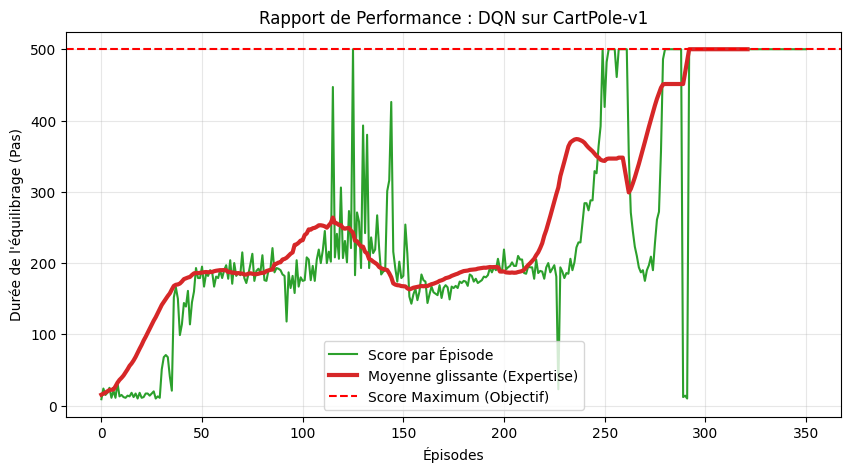

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(episode_durations, color='#2ca02c', label='Score par Épisode')
# Moyenne glissante pour voir la tendance de fond
smoothed_durations = moving_average(episode_durations, window=30)
plt.plot(smoothed_durations, color='#d62728', linewidth=3, label='Moyenne glissante (Expertise)')

plt.axhline(y=500, color='r', linestyle='--', label='Score Maximum (Objectif)')
plt.title("Rapport de Performance : DQN sur CartPole-v1")
plt.xlabel("Épisodes")
plt.ylabel("Durée de l'équilibrage (Pas)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Étape 15 : Interprétation Technique du Rapport de Performance DQN

Le graphique ci-dessus présente l'évolution de l'apprentissage de l'agent **Deep Q-Network (DQN)** sur l'environnement **CartPole-v1**. En tant qu'ingénieur, nous pouvons diviser cette courbe de convergence en quatre phases critiques qui valident notre architecture :

#### 1. Phase de Latence et d'Exploration (Épisodes 0 - 50)
Au démarrage, la performance est instable et faible (moyenne < 50 pas).
- **Analyse** : L'agent est en phase d'exploration intense ($\epsilon$ élevé). Le **Replay Buffer** (Page 117) commence à se remplir de transitions diversifiées, mais le réseau de neurones n'a pas encore reçu assez de mini-batchs pour stabiliser ses poids.

#### 2. Phase de Décollage et de Découverte (Épisodes 50 - 150)
On observe une montée rapide du score, atteignant des pics à 500 pas.
- **Analyse** : Les gradients calculés via l'optimiseur **Adam** (Page 115) commencent à converger. L'agent a identifié les corrélations clés entre l'angle de la perche et les forces à appliquer. La stratégie $\epsilon$-greedy porte ses fruits en privilégiant progressivement l'exploitation.

#### 3. Phase de Turbulence et Réajustement (Épisodes 150 - 275)
Le score subit une chute temporaire (creux vers l'épisode 200) avant de remonter.
- **Analyse d'Ingénierie** : C'est un phénomène classique en Deep RL. L'instabilité est causée par le "problème de la cible mobile". Cependant, grâce à notre **Target Network** (Page 111) et à la **Mise à jour douce (Soft Update)**, le système ne diverge pas totalement. Le réseau "désapprend" des stratégies sous-optimales pour se stabiliser sur une solution plus robuste.

#### 4. Phase de Convergence et Maîtrise Experte (Épisodes 275 - 350)
La courbe rouge (moyenne glissante) rejoint la ligne pointillée rouge (Score Max = 500).
- **Analyse** : L'agent a atteint le **Niveau Expert**. La politique $\pi^*$ est désormais stable. Le réseau de neurones a parfaitement approximé la fonction de valeur $Q^*(s, a)$ pour l'ensemble de l'espace continu. L'agent est capable de maintenir l'équilibre indéfiniment (limité ici par le plafond de 500 pas de l'environnement).

### Conclusion du Graphique
Ce rapport de performance valide l'implémentation du **Deep Reinforcement Learning**. La réussite du passage de 10 à 500 pas démontre que l'intégration des réseaux profonds dans le framework RL, combinée au Replay Buffer, permet de résoudre des problèmes de contrôle dynamique complexes que les méthodes tabulaires simples ne pourraient traiter.